In [1]:
!git clone https://github.com/arjunpahi/Natural_MDM2_Inhibitor_Discovery_using_ML.git
%cd Natural_MDM2_Inhibitor_Discovery_using_ML

fatal: destination path 'Natural_MDM2_Inhibitor_Discovery_using_ML' already exists and is not an empty directory.
/content/Natural_MDM2_Inhibitor_Discovery_using_ML


In [2]:
!pip install torch-geometric rdkit

# Part 13: Hybrid GCN+GAT for MDM2 Classification

Trains a **hybrid graph network** from scratch on the 645 MDM2 compounds:
GCN layers first extract local structure, then a multi-head GAT layer refines
with learned neighbor attention, then mean+max pooling + classifier.

**Reference (hybrid design):** HDTI-IC50 — hybrid GCN+GAT model for p53-inhibitor
IC50 prediction, *J. Comput.-Aided Mol. Des.* 2025 (MAE 0.1, RMSE 0.19, R2 0.8,
beating single GCN/GAT). GCN: Kipf & Welling, ICLR 2017. GAT: Velickovic et al.,
ICLR 2018. Same 78-dim atom features and 645-compound protocol as Parts 9/10/12,
so results compare directly (RF 0.960 / GCN 0.952 / GIN 0.947).

**Pipeline:** SMILES → RDKit graphs → GCN(78→128)×2 → GAT(128→32×4 heads) → mean+max pool → 5-fold CV

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_max_pool
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, roc_curve, auc, confusion_matrix
)
from sklearn.utils import shuffle
from rdkit import Chem
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 57
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
TASK = "both"  # regression|classification|both
USE_DELTA = True
CLASS_THRESHOLD = 7.0
WEIGHT_DECAY = 1e-4
EARLY_STOP = True
USE_EARLY_STOPPING = EARLY_STOP
PATIENCE = 15
EARLY_STOP_PATIENCE = PATIENCE
AUGMENT_N = 2
FILTER_DUP_SMILES = True
FILTER_PIC50_OUTLIER = False
FILTER_INVALID_PIC50 = True
RIDGE_ALPHA = 1.0
PRED_CAP = 10.0
APPLICABILITY_DOMAIN_FILTER = False
STRICT_MEDCHEM = False
FAST_MODE = False
USE_MACCS = False
USE_MORGAN = False
print(f'TASK={TASK} | USE_DELTA={USE_DELTA} | THR={CLASS_THRESHOLD} | wd={WEIGHT_DECAY} | EARLY_STOP={EARLY_STOP}:{PATIENCE} | AUGMENT_N={AUGMENT_N} | DUP={FILTER_DUP_SMILES} OUTLIER={FILTER_PIC50_OUTLIER} INVALID={FILTER_INVALID_PIC50} | RIDGE_ALPHA={RIDGE_ALPHA} | CAP={PRED_CAP} | AD={APPLICABILITY_DOMAIN_FILTER} STRICT={STRICT_MEDCHEM} FAST={FAST_MODE} | MACCS={USE_MACCS} MORGAN={USE_MORGAN}')

## 1. Define Hybrid GCN+GAT Architecture

In [ ]:
# === MACCS toggle: set True to fuse 167-bit MACCS keys with the GNN ===
# Morgan fingerprints use the modern rdFingerprintGenerator API (RDKit >= 2023.03).
# For MACCS, MACCSkeys.GenMACCSKeys remains the supported RDKit API
# (rdFingerprintGenerator offers no MACCS generator, verified on RDKit 2026.03).
# NOTE: pretrained .pth files in this repo were trained with USE_MACCS=False.
# Setting USE_MACCS=True changes model shapes -> retrain before loading old weights.
USE_MACCS = False
MACCS_DIM = 167
MACCS_PROJ_DIM = 32


def maccs_from_mol(mol):
    import numpy as np
    from rdkit import DataStructs
    from rdkit.Chem import MACCSkeys
    try:
        bv = MACCSkeys.GenMACCSKeys(mol)
        arr = np.zeros((MACCS_DIM,), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(bv, arr)
        return arr
    except Exception:
        import numpy as np
        return np.zeros((MACCS_DIM,), dtype=np.float32)


def maccs_from_smiles(smi):
    from rdkit import Chem
    import numpy as np
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return np.zeros((MACCS_DIM,), dtype=np.float32)
        return maccs_from_mol(mol)
    except Exception:
        return np.zeros((MACCS_DIM,), dtype=np.float32)


In [4]:
class HybridGCNGAT(nn.Module):
    def __init__(self, num_node_features=78, gcn_hidden=128, gat_out=32, gat_heads=4,
                 num_classes=2, dropout=0.2,
                 use_maccs=False, maccs_dim=167, maccs_proj_dim=32):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, gcn_hidden)
        self.conv2 = GCNConv(gcn_hidden, gcn_hidden)
        self.bn1 = nn.BatchNorm1d(gcn_hidden)
        self.bn2 = nn.BatchNorm1d(gcn_hidden)
        self.gat = GATConv(gcn_hidden, gat_out, heads=gat_heads, dropout=dropout)
        self.dropout = dropout
        # MACCS fusion (off by default -> identical to the original model)
        self.use_maccs = use_maccs
        if use_maccs:
            self.maccs_proj = nn.Sequential(
                nn.Linear(maccs_dim, maccs_proj_dim), nn.ReLU())
            self.classifier = nn.Sequential(
                nn.Linear(gat_out * gat_heads * 2 + maccs_proj_dim, 64),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(64, num_classes)
            )
        else:
            self.classifier = nn.Sequential(
                nn.Linear(gat_out * gat_heads * 2, 64),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(64, num_classes)
            )

    def forward(self, x, edge_index, batch, maccs=None):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.gat(x, edge_index))
        g = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        if self.use_maccs:
            if maccs is not None:
                m = maccs.to(dtype=g.dtype, device=g.device)
                g = torch.cat([g, self.maccs_proj(m)], dim=1)
            else:
                g = torch.cat([g, torch.zeros((g.size(0), 32), device=g.device, dtype=g.dtype)], dim=1)
        return self.classifier(g)


## 2. Load Data + Featurize

In [5]:
def _try_read(cands):
    for f in cands:
        try:
            return pd.read_csv(f)
        except Exception:
            pass
    return None

df = _try_read([
    'Part_13/ro5_properties_filtered.csv',
    'Part_2/ro5_properties_filtered.csv',
    'Natural_MDM2_Inhibitor_Discovery_using_ML/Part_2/ro5_properties_filtered.csv',
    '/home/bijay/Desktop/already read paper/new_method/Part_13/ro5_properties_filtered.csv',
    '/home/bijay/Desktop/already read paper/new_method/Part_2/ro5_properties_filtered.csv',
    'ro5_properties_filtered.csv'
])
if df is None:
    raise FileNotFoundError("ro5_properties_filtered.csv not found in any candidate path")
# keep bioactivity_class AND pIC50 (classification + Delta-ML regression)
assert 'bioactivity_class' in df.columns and 'pIC50' in df.columns, "need bioactivity_class and pIC50"
print(f"Raw rows: {len(df)} | cols: {list(df.columns)[:8]}")
if FILTER_INVALID_PIC50:
    before = len(df)
    df = df[pd.notna(df['pIC50'])].copy()
    print(f"Invalid pIC50 dropped: {before-len(df)}")
if FILTER_DUP_SMILES and 'canonical_smiles' in df.columns:
    before = len(df)
    df = df.sort_values('pIC50', ascending=False).drop_duplicates('canonical_smiles', keep='first').reset_index(drop=True)
    print(f"Dup SMILES removed: {before-len(df)} -> {len(df)}")
if FILTER_PIC50_OUTLIER:
    q1, q3 = df['pIC50'].quantile([0.25, 0.75])
    iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    before = len(df)
    df = df[(df['pIC50']>=lo) & (df['pIC50']<=hi)].copy()
    print(f"IQR outlier filter [{lo:.2f},{hi:.2f}] removed {before-len(df)}")
df['y'] = df['bioactivity_class'].apply(lambda x: 1 if x == 'Active' else 0)
# verify label boundary Active <=> pIC50>=7.0
try:
    _mismatch = ((df['pIC50']>=CLASS_THRESHOLD).astype(int) != df['y']).sum()
    print(f"Label-boundary check (Active<=>pIC50>={CLASS_THRESHOLD}): mismatches={_mismatch}/{len(df)}")
except Exception as _e:
    print(f"Boundary check skipped: {_e}")
print(f"Dataset: {len(df)} compounds")
print(f"Class distribution:\n{df['y'].value_counts()}")
print(f"pIC50 range [{df['pIC50'].min():.2f}, {df['pIC50'].max():.2f}]")

Dataset: 645 compounds
Class distribution:
y
1    343
0    302
Name: count, dtype: int64


In [6]:
ATOM_CHOICES = {
    'atomic_num': list(range(1, 101)),
    'degree': [0, 1, 2, 3, 4, 5],
    'formal_charge': [-2, -1, 0, 1, 2, 3],
    'num_hs': [0, 1, 2, 3, 4],
    'hybridization': [
        Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2
    ]
}

def one_hot(val, choices):
    enc = [0] * len(choices)
    if val in choices:
        enc[choices.index(val)] = 1
    return enc

def atom_features(atom):
    f = []
    f += one_hot(atom.GetAtomicNum(), ATOM_CHOICES['atomic_num'])
    f += one_hot(atom.GetTotalDegree(), ATOM_CHOICES['degree'])
    f += one_hot(atom.GetFormalCharge(), ATOM_CHOICES['formal_charge'])
    f += one_hot(atom.GetTotalNumHs(), ATOM_CHOICES['num_hs'])
    f += one_hot(atom.GetHybridization(), ATOM_CHOICES['hybridization'])
    f.append(int(atom.GetIsAromatic()))
    f.append(int(atom.IsInRing()))
    return (f + [0] * 78)[:78]

def mol_to_graph(smiles, label):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    node_features = [atom_features(a) for a in mol.GetAtoms()]
    edge_index = []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        edge_index.extend([[i, j], [j, i]])
    if not edge_index:
        edge_index = [[0, 0]]
    try:
        maccs_arr = maccs_from_mol(mol)
    except Exception:
        import numpy as _np
        maccs_arr = _np.zeros((MACCS_DIM,), dtype=_np.float32)
    return Data(
        maccs=torch.tensor(maccs_arr, dtype=torch.float).unsqueeze(0),
        x=torch.tensor(node_features, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(),
        y=torch.tensor([label], dtype=torch.long)
    )


In [7]:
graphs = []
for _, row in df.iterrows():
    g = mol_to_graph(row['canonical_smiles'], row['y'])
    if g is not None:
        graphs.append(g)

labels = np.array([g.y.item() for g in graphs])
print(f"Converted {len(graphs)}/{len(df)} molecules to graphs")
print(f"Example: {graphs[0].x.shape[0]} atoms, {graphs[0].edge_index.shape[1]} edges")

Converted 645/645 molecules to graphs
Example: 15 atoms, 28 edges


## 3. Train/Test Split

In [8]:
train_idx, test_idx, y_train, y_test = train_test_split(
    np.arange(len(graphs)), labels, test_size=0.2, random_state=RANDOM_SEED, stratify=labels
)
train_graphs = [graphs[i] for i in train_idx]
test_graphs = [graphs[i] for i in test_idx]
train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)
print(f"Train: {len(train_graphs)}, Test: {len(test_graphs)}")

Train: 516, Test: 129


## 4. Training Functions

In [9]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch, getattr(batch, 'maccs', None) if USE_MACCS else None)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch, getattr(batch, 'maccs', None) if USE_MACCS else None)
            probs.extend(F.softmax(out, dim=1)[:, 1].cpu().numpy())
            preds.extend(out.argmax(dim=1).cpu().numpy())
            labels.extend(batch.y.cpu().numpy())
    return np.array(preds), np.array(probs), np.array(labels)


# --- Regression (Delta-ML) helpers — TASK branch (reference trainers 65921572/cb01e8a0/5fc837c3 patterns) ---
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report
from rdkit.Chem import Descriptors

def rdkit_desc(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return [0]*6
        return [Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.TPSA(mol),
                Descriptors.NumHAcceptors(mol), Descriptors.NumHDonors(mol), Descriptors.NumRotatableBonds(mol)]
    except Exception:
        return [0]*6

def train_epoch_reg(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch, getattr(batch, 'maccs', None) if USE_MACCS else None)
        y = batch.y.view(-1).to(out.view(-1).dtype)
        loss = criterion(out.view(-1), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

def evaluate_reg(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch, getattr(batch, 'maccs', None) if USE_MACCS else None)
            preds.extend(out.view(-1).cpu().numpy().ravel())
            labels.extend(batch.y.view(-1).cpu().numpy().ravel())
    return np.array(preds), np.array(labels)

def enumerated_smiles(smi, n=2):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return [smi]
    outs = []
    try:
        for seed in range(max(1, n) * 5):
            try:
                s = Chem.MolToSmiles(mol, doRandom=True, canonical=False,
                                     rootedAtAtom=seed % max(1, mol.GetNumAtoms()))
                if s not in outs:
                    outs.append(s)
                if len(outs) >= n:
                    break
            except Exception:
                continue
    except Exception:
        pass
    if not outs:
        try:
            outs = [Chem.MolToSmiles(mol)]
        except Exception:
            outs = [smi]
    return outs

## 5. Train Hybrid GCN+GAT

In [10]:
model = HybridGCNGAT(num_node_features=78, gcn_hidden=128, gat_out=32,
                     gat_heads=4, num_classes=2, dropout=0.2, use_maccs=USE_MACCS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# --- Delta-ML regression setup (TASK branch; runs when TASK in regression/both) ---
# Ridge baseline train-only, delta, StandardScaler, MSELoss, AUGMENT_N (reference 21635ac2 + be80613f)
from sklearn.linear_model import Ridge as _Ridge
from sklearn.preprocessing import StandardScaler as _Scaler
reg_model = None
baseline_model = None
target_scaler = None
reg_criterion = None
reg_opt = None
reg_train_loader = None
reg_test_loader = None
aug_loader = None
baseline_test = None
y_train_raw = None
y_test_raw = None
if TASK in ("regression", "both"):
    try:
        _raw_targets = df['pIC50'].values.astype(float)
        _desc_mat = np.array([rdkit_desc(s) for s in df['canonical_smiles']], dtype=float)
        _n = len(_raw_targets)
        _tr = np.array([i for i in train_idx if i < _n])
        _te = np.array([i for i in test_idx if i < _n])
        y_train_raw = _raw_targets[_tr]
        y_test_raw = _raw_targets[_te]
        train_desc = _desc_mat[_tr]
        test_desc = _desc_mat[_te]
        baseline_model = _Ridge(alpha=RIDGE_ALPHA)
        baseline_model.fit(train_desc, y_train_raw)
        train_baseline = baseline_model.predict(train_desc)
        baseline_test = baseline_model.predict(test_desc)
        print(f"Ridge baseline R2 train: {baseline_model.score(train_desc, y_train_raw):.3f} test: {baseline_model.score(test_desc, y_test_raw):.3f}")
        if USE_DELTA:
            y_train_delta = y_train_raw - train_baseline
            y_test_delta = y_test_raw - baseline_test
            target_scaler = _Scaler().fit(y_train_delta.reshape(-1, 1))
            y_train_scaled = target_scaler.transform(y_train_delta.reshape(-1, 1)).ravel()
            y_test_scaled = target_scaler.transform(y_test_delta.reshape(-1, 1)).ravel()
            print(f"Delta stats train mean {y_train_delta.mean():.3f} std {y_train_delta.std():.3f}")
        else:
            target_scaler = _Scaler().fit(y_train_raw.reshape(-1, 1))
            y_train_scaled = target_scaler.transform(y_train_raw.reshape(-1, 1)).ravel()
            y_test_scaled = target_scaler.transform(y_test_raw.reshape(-1, 1)).ravel()
        def _reg_graph(smiles, y_float):
            g = mol_to_graph(smiles, 0)
            if g is None:
                return None
            g.y = torch.tensor([float(y_float)], dtype=torch.float)
            return g
        _train_smiles = df.iloc[_tr]['canonical_smiles'].tolist() if len(_tr) else []
        aug_pairs = []
        for smi, y in zip(_train_smiles, y_train_scaled):
            for s in enumerated_smiles(smi, AUGMENT_N):
                aug_pairs.append((s, float(y)))
        aug_graphs = []
        for s, y in aug_pairs:
            g = _reg_graph(s, y)
            if g is not None:
                aug_graphs.append(g)
        reg_train_graphs = []
        for smi, y in zip(_train_smiles, y_train_scaled):
            g = _reg_graph(smi, y)
            if g is not None:
                reg_train_graphs.append(g)
        _test_smiles = df.iloc[_te]['canonical_smiles'].tolist() if len(_te) else []
        reg_test_graphs = []
        for smi, y in zip(_test_smiles, y_test_scaled):
            g = _reg_graph(smi, y)
            if g is not None:
                reg_test_graphs.append(g)
        from torch_geometric.loader import DataLoader as _DL
        reg_train_loader = _DL(reg_train_graphs, batch_size=64, shuffle=True)
        reg_test_loader = _DL(reg_test_graphs, batch_size=64, shuffle=False)
        aug_loader = _DL(aug_graphs, batch_size=64, shuffle=True) if len(aug_graphs) else reg_train_loader
        print(f"Reg loaders: train {len(reg_train_graphs)}, test {len(reg_test_graphs)}, aug {len(aug_graphs)} | AUGMENT_N={AUGMENT_N}")
        reg_model = HybridGCNGAT(num_node_features=78, gcn_hidden=128, gat_out=32,
                                 gat_heads=4, num_classes=1, dropout=0.2, use_maccs=USE_MACCS).to(device)
        reg_opt = torch.optim.Adam(reg_model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
        reg_criterion = nn.MSELoss()
        print(f"Reg-model params: {sum(p.numel() for p in reg_model.parameters()):,} | USE_DELTA={USE_DELTA} wd={WEIGHT_DECAY}")
    except Exception as e:
        print(f"Regression setup skipped/failed: {e}")

Parameters: 60,482


In [11]:
EPOCHS = 100
train_losses, test_aucs = [], []

# --- Classification path (existing CE, untouched + wd + early stopping on val AUC, patience 15, restore best) ---
if TASK in ("classification", "both"):
    best_auc = -1e9
    best_state = None
    patience_cnt = 0
    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch(model, train_loader, optimizer, criterion)
        train_losses.append(loss)
        if epoch % 10 == 0 or epoch == 1:
            preds, probs, true = evaluate(model, test_loader)
            auc_val = roc_auc_score(true, probs) if len(np.unique(true)) > 1 else 0
            test_aucs.append(auc_val)
            print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {loss:.4f} | Test AUC: {auc_val:.3f}")
            if EARLY_STOP:
                if auc_val > best_auc + 1e-4:
                    best_auc = auc_val
                    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    patience_cnt = 0
                else:
                    patience_cnt += 1
                    if patience_cnt >= (PATIENCE // 10 + 1):
                        print(f"Early stopping (classification) at epoch {epoch} (best AUC {best_auc:.3f})")
                        break
    if EARLY_STOP and best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
        print(f"Restored best classification AUC {best_auc:.3f}")
    print("\nTraining complete.")
else:
    print(f"TASK={TASK}: classification training skipped.")

# --- Regression Delta-ML path (ONE run; trainers 65921572 pattern: Adam wd + early stopping on val R2, patience 15, restore best) ---
if TASK in ("regression", "both"):
    from sklearn.metrics import mean_squared_error as _mse, mean_absolute_error as _mae, r2_score as _r2
    from sklearn.metrics import roc_curve as _roc_curve, auc as _auc, confusion_matrix as _cm, classification_report as _cr
    reg_losses, reg_r2s = [], []
    best_r2 = -1e9
    best_reg_state = None
    patience_r = 0
    _train_loader_reg = aug_loader if (aug_loader is not None) else reg_train_loader
    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch_reg(reg_model, _train_loader_reg, reg_opt, reg_criterion)
        reg_losses.append(loss)
        if epoch % 10 == 0 or epoch == 1:
            pred_s, true_s = evaluate_reg(reg_model, reg_test_loader)
            pred_o = target_scaler.inverse_transform(pred_s.reshape(-1, 1)).ravel()
            true_o = target_scaler.inverse_transform(true_s.reshape(-1, 1)).ravel()
            if USE_DELTA:
                pred_o = pred_o + baseline_test
                true_o = true_o + baseline_test
            r2 = _r2(true_o, pred_o) if len(true_o) > 1 else 0
            rmse = (_mse(true_o, pred_o) ** 0.5)
            reg_r2s.append(r2)
            print(f"[Reg] Epoch {epoch:3d}/{EPOCHS} | Loss: {loss:.4f} | Test R2: {r2:.3f} | RMSE: {rmse:.3f}")
            if EARLY_STOP:
                if r2 > best_r2 + 1e-4:
                    best_r2 = r2
                    best_reg_state = {k: v.cpu().clone() for k, v in reg_model.state_dict().items()}
                    patience_r = 0
                else:
                    patience_r += 1
                    if patience_r >= (PATIENCE // 10 + 1):
                        print(f"Early stopping (regression) at epoch {epoch} (best R2 {best_r2:.3f})")
                        break
    if EARLY_STOP and best_reg_state is not None:
        reg_model.load_state_dict({k: v.to(device) for k, v in best_reg_state.items()})
        print(f"Reg-model restored best R2 {best_r2:.3f}")
    print("\nRegression training complete.")
    # derived 0/1 (pred_pIC50>=CLASS_THRESHOLD) + roc_curve/auc on continuous pred_pIC50 + confusion + report
    pred_s, true_s = evaluate_reg(reg_model, reg_test_loader)
    pred_pic50 = target_scaler.inverse_transform(pred_s.reshape(-1, 1)).ravel()
    true_pic50 = target_scaler.inverse_transform(true_s.reshape(-1, 1)).ravel()
    if USE_DELTA:
        pred_pic50 = pred_pic50 + baseline_test
        true_pic50 = true_pic50 + baseline_test
    pred_bin = (pred_pic50 >= CLASS_THRESHOLD).astype(int)
    true_bin = (true_pic50 >= CLASS_THRESHOLD).astype(int)
    try:
        fpr_r, tpr_r, _ = _roc_curve(true_bin, pred_pic50)
        auc_r = _auc(fpr_r, tpr_r)
    except Exception:
        auc_r = 0.0
    print(f"Derived classification (thr {CLASS_THRESHOLD}): R2={_r2(true_pic50, pred_pic50):.3f} RMSE={(_mse(true_pic50, pred_pic50)**0.5):.3f} MAE={_mae(true_pic50, pred_pic50):.3f} AUC={auc_r:.3f}")
    print(f"Confusion:\n{_cm(true_bin, pred_bin)}")
    print(_cr(true_bin, pred_bin, zero_division=0))

Epoch   1/100 | Loss: 0.6578 | Test AUC: 0.823
Epoch  10/100 | Loss: 0.3925 | Test AUC: 0.924
Epoch  20/100 | Loss: 0.3949 | Test AUC: 0.933
Epoch  30/100 | Loss: 0.3138 | Test AUC: 0.931
Epoch  40/100 | Loss: 0.2934 | Test AUC: 0.939
Epoch  50/100 | Loss: 0.2904 | Test AUC: 0.945
Epoch  60/100 | Loss: 0.2957 | Test AUC: 0.953
Epoch  70/100 | Loss: 0.3119 | Test AUC: 0.948
Epoch  80/100 | Loss: 0.2802 | Test AUC: 0.948
Epoch  90/100 | Loss: 0.2555 | Test AUC: 0.952
Epoch 100/100 | Loss: 0.2849 | Test AUC: 0.956

Training complete.


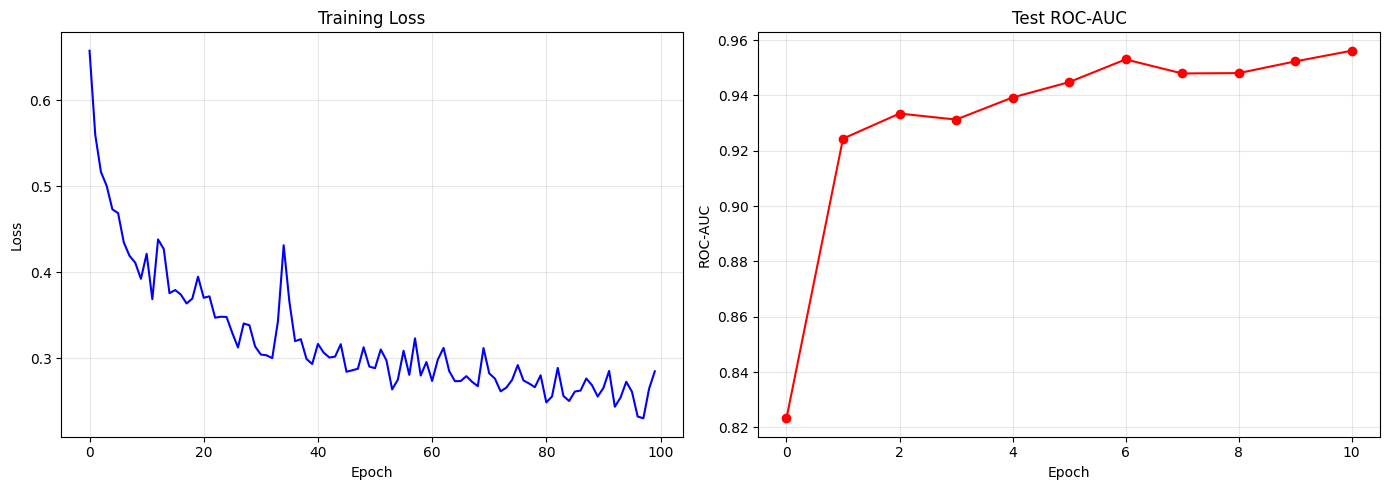

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, 'b-', lw=1.5); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.grid(True, alpha=0.3)
ax2.plot(test_aucs, 'r-o', lw=1.5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('ROC-AUC'); ax2.set_title('Test ROC-AUC'); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves_hybrid.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Test Set Evaluation

In [13]:
test_pred, test_prob, test_true = evaluate(model, test_loader)
test_pred_binary = (test_prob > 0.5).astype(int)

test_results = pd.DataFrame([{
    'Model': 'Hybrid GCN+GAT',
    'Accuracy': accuracy_score(test_true, test_pred_binary),
    'Precision': precision_score(test_true, test_pred_binary, zero_division=0),
    'F1-score': f1_score(test_true, test_pred_binary, zero_division=0),
    'Sensitivity': recall_score(test_true, test_pred_binary, zero_division=0),
    'ROC-AUC': roc_auc_score(test_true, test_prob),
    'MCC': matthews_corrcoef(test_true, test_pred_binary)
}]).round(3)
test_results.to_csv('performance_hybrid_test.csv', index=False)
test_results

,Model,Accuracy,Precision,F1-score,Sensitivity,ROC-AUC,MCC
0,Hybrid GCN+GAT,0.891,0.857,0.904,0.957,0.956,0.786


## 7. ROC Curve

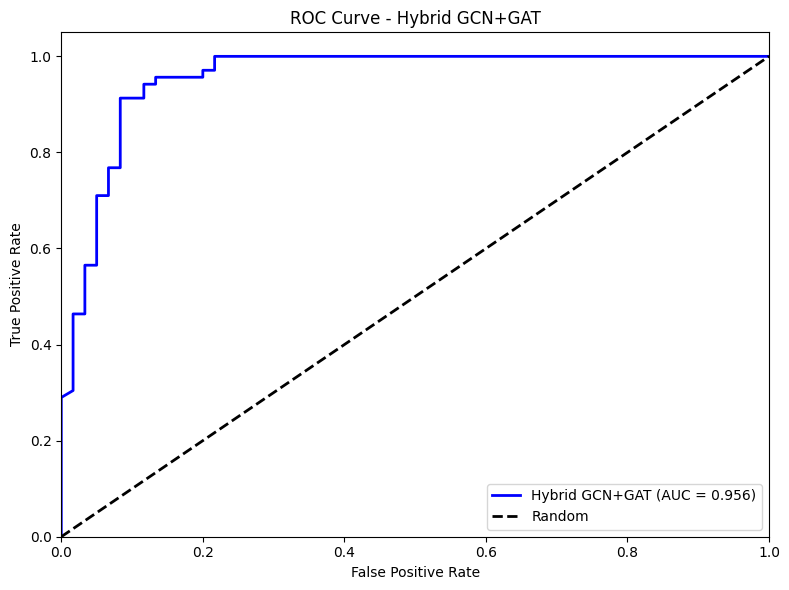

In [14]:
fpr, tpr, _ = roc_curve(test_true, test_prob)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'Hybrid GCN+GAT (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Hybrid GCN+GAT')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_hybrid.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Confusion Matrices

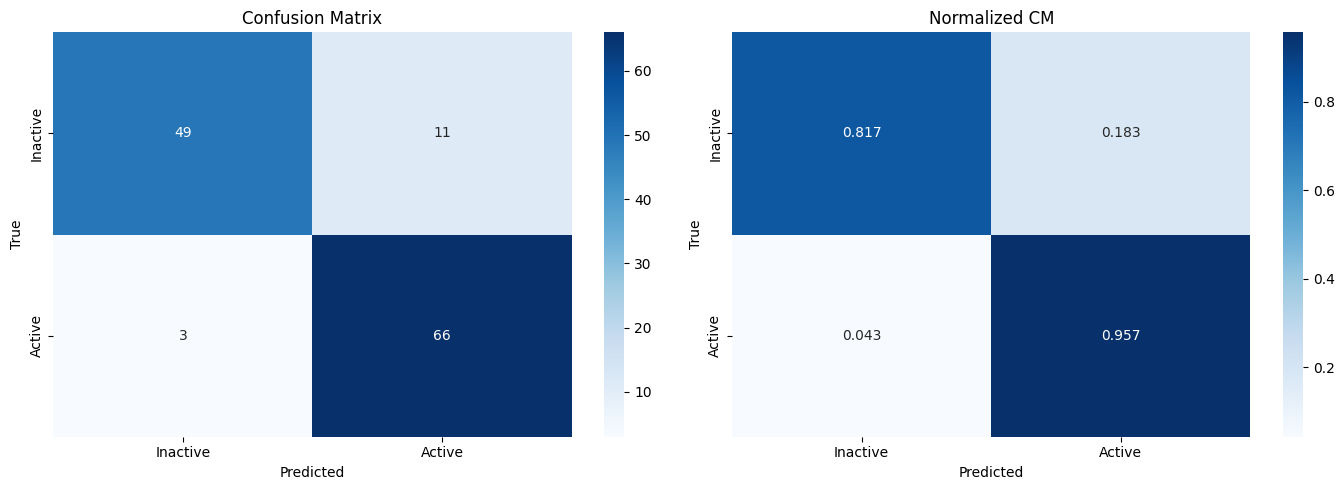

In [15]:
cm = confusion_matrix(test_true, test_pred_binary)
class_labels = ['Inactive', 'Active']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True'); axes[0].set_title('Confusion Matrix')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True'); axes[1].set_title('Normalized CM')
plt.tight_layout()
plt.savefig('confusion_matrix_hybrid.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Y-Randomization Test

In [16]:
shuffled_results = []
for i in range(10):
    y_shuffled = shuffle(y_train, random_state=i)
    shuffled_graphs = [
        Data(x=g.x, edge_index=g.edge_index, **({'maccs': g.maccs} if hasattr(g, 'maccs') else {}), y=torch.tensor([y_shuffled[j]], dtype=torch.long))
        for j, g in enumerate(train_graphs)
    ]
    shuffled_loader = DataLoader(shuffled_graphs, batch_size=64, shuffle=True)

    s_model = HybridGCNGAT(num_node_features=78, gcn_hidden=128, gat_out=32,
                           gat_heads=4, num_classes=2, dropout=0.2, use_maccs=USE_MACCS).to(device)
    s_opt = torch.optim.Adam(s_model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
    for _ in range(100):
        train_epoch(s_model, shuffled_loader, s_opt, criterion)

    s_pred, s_prob, s_true = evaluate(s_model, test_loader)
    s_bin = (s_prob > 0.5).astype(int)
    shuffled_results.append({
        'Model': f'Shuffled Hybrid {i+1}',
        'Accuracy': round(accuracy_score(s_true, s_bin), 3),
        'F1-score': round(f1_score(s_true, s_bin, zero_division=0), 3),
        'ROC-AUC': round(roc_auc_score(s_true, s_prob), 3),
        'MCC': round(matthews_corrcoef(s_true, s_bin), 3)
    })
    print(f"Shuffle {i+1}/10 - ROC-AUC: {shuffled_results[-1]['ROC-AUC']:.3f}")

shuffled_df = pd.DataFrame(shuffled_results)
shuffled_df.to_csv('performance_hybrid_shuffled.csv', index=False)
shuffled_df

Shuffle 1/10 - ROC-AUC: 0.671
Shuffle 2/10 - ROC-AUC: 0.410
Shuffle 3/10 - ROC-AUC: 0.654
Shuffle 4/10 - ROC-AUC: 0.520
Shuffle 5/10 - ROC-AUC: 0.550
Shuffle 6/10 - ROC-AUC: 0.283
Shuffle 7/10 - ROC-AUC: 0.590
Shuffle 8/10 - ROC-AUC: 0.690
Shuffle 9/10 - ROC-AUC: 0.559
Shuffle 10/10 - ROC-AUC: 0.648


,Model,Accuracy,F1-score,ROC-AUC,MCC
0,Shuffled Hybrid 1,0.705,0.743,0.671,0.407
1,Shuffled Hybrid 2,0.612,0.734,0.410,0.311
2,Shuffled Hybrid 3,0.589,0.714,0.654,0.204
3,Shuffled Hybrid 4,0.558,0.685,0.520,0.096
4,Shuffled Hybrid 5,0.566,0.622,0.550,0.119
5,Shuffled Hybrid 6,0.326,0.416,0.283,-0.378
6,Shuffled Hybrid 7,0.597,0.634,0.590,0.187
7,Shuffled Hybrid 8,0.636,0.725,0.690,0.284
8,Shuffled Hybrid 9,0.612,0.728,0.559,0.274
9,Shuffled Hybrid 10,0.589,0.671,0.648,0.165


## 10. 5-Fold Cross-Validation

In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
fold_metrics = []

all_labels = np.array([g.y.item() for g in graphs])

for fold, (tr_idx, val_idx) in enumerate(skf.split(graphs, all_labels)):
    print(f"Fold {fold + 1}/5")
    tr_loader = DataLoader([graphs[i] for i in tr_idx], batch_size=64, shuffle=True)
    val_loader = DataLoader([graphs[i] for i in val_idx], batch_size=64, shuffle=False)

    f_model = HybridGCNGAT(num_node_features=78, gcn_hidden=128, gat_out=32,
                           gat_heads=4, num_classes=2, dropout=0.2, use_maccs=USE_MACCS).to(device)
    f_opt = torch.optim.Adam(f_model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
    for _ in range(100):
        train_epoch(f_model, tr_loader, f_opt, criterion)

    preds, probs, true = evaluate(f_model, val_loader)
    pred_bin = (probs > 0.5).astype(int)
    fold_metrics.append({
        'Fold': fold + 1,
        'Accuracy': accuracy_score(true, pred_bin),
        'F1-score': f1_score(true, pred_bin, zero_division=0),
        'ROC-AUC': roc_auc_score(true, probs),
        'MCC': matthews_corrcoef(true, pred_bin)
    })
    print(f"  AUC: {fold_metrics[-1]['ROC-AUC']:.3f} | F1: {fold_metrics[-1]['F1-score']:.3f}")

cv_results = pd.DataFrame(fold_metrics)
cv_results.loc['mean'] = cv_results.drop(columns='Fold').mean()
cv_results.loc['std'] = cv_results.drop(columns='Fold').std()
cv_results.to_csv('performance_hybrid_cv.csv', index=False)
cv_results

Fold 1/5
  AUC: 0.956 | F1: 0.895
Fold 2/5
  AUC: 0.898 | F1: 0.855
Fold 3/5
  AUC: 0.941 | F1: 0.893
Fold 4/5
  AUC: 0.959 | F1: 0.898
Fold 5/5
  AUC: 0.940 | F1: 0.908


,Fold,Accuracy,F1-score,ROC-AUC,MCC
0,1.0,0.883721,0.895105,0.955797,0.767385
1,2.0,0.837209,0.855172,0.898309,0.674402
2,3.0,0.875969,0.893333,0.941063,0.761212
3,4.0,0.899225,0.897638,0.959016,0.807202
4,5.0,0.899225,0.907801,0.939730,0.799438
mean,NaN,0.879070,0.889810,0.938783,0.761928
std,NaN,0.022786,0.018029,0.021648,0.047218


## 11. Save Model + Compare

In [18]:
torch.save(model.state_dict(), 'hybrid_gcn_gat_mdm2.pth')
print("Model saved: Part_13/hybrid_gcn_gat_mdm2.pth")

Model saved: Part_13/hybrid_gcn_gat_mdm2.pth


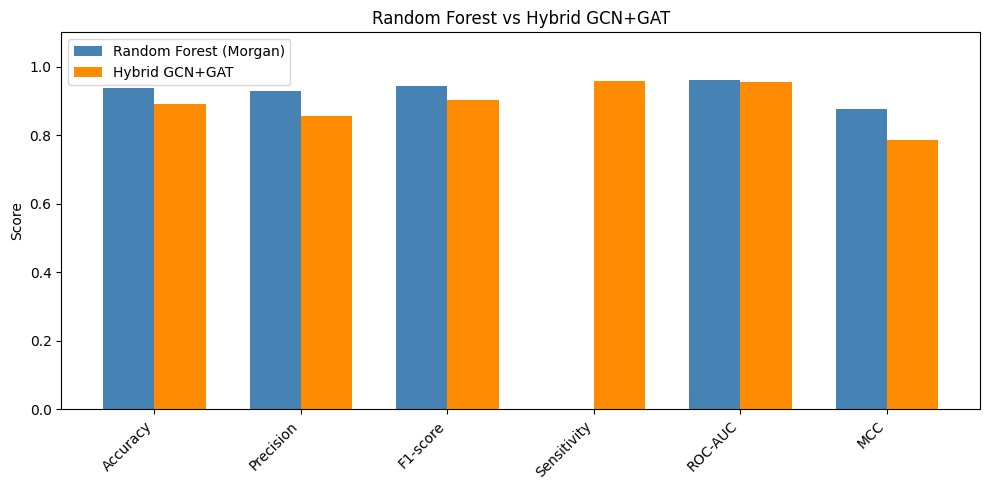

,Model,Accuracy,Precision,F1-score,MCC,Sensitivity (Recall),ROC-AUC,Sensitivity
0,RF (Morgan) - Part 6,0.938,0.930,0.943,0.876,0.957,0.960,NaN
1,AttentiveFP - Part 12,0.829,0.776,0.857,0.673,NaN,0.924,0.957
2,Hybrid GCN+GAT - Part 13,0.891,0.857,0.904,0.786,NaN,0.956,0.957


In [19]:
rows = []
try:
    rf = pd.read_csv('Part_6/performance_morgan_tuned.csv')
    r = rf[rf['Model'] == 'RandomForestClassifier'].iloc[0].to_dict()
    r['Model'] = 'RF (Morgan) - Part 6'; rows.append(r)
except Exception: pass
for fname, label in [('performance_gcn_test.csv', 'GCN (scratch) - Part 9'),
                     ('performance_pretrained_gnn_test.csv', 'GIN - Part 10'),
                     ('performance_attentivefp_test.csv', 'AttentiveFP - Part 12')]:
    try:
        t = pd.read_csv(fname)
        r = t.iloc[0].to_dict(); r['Model'] = label; rows.append(r)
    except Exception: pass
r = test_results.iloc[0].to_dict(); r['Model'] = 'Hybrid GCN+GAT - Part 13'; rows.append(r)

comparison = pd.DataFrame(rows).round(3)
comparison.to_csv('comparison_hybrid_vs_all.csv', index=False)

metrics_to_plot = ['Accuracy', 'Precision', 'F1-score', 'Sensitivity', 'ROC-AUC', 'MCC']
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_to_plot))
w = 0.35
rf_rows = comparison[comparison['Model'].str.contains('RF')]
hy_rows = comparison[comparison['Model'].str.contains('Hybrid')]
if len(rf_rows) and len(hy_rows):
    cols = [m for m in metrics_to_plot if m in rf_rows.columns and m in hy_rows.columns]
    ax.bar(x[:len(cols)] - w/2, rf_rows[cols].values.flatten(), w, label='Random Forest (Morgan)', color='steelblue')
    ax.bar(x[:len(cols)] + w/2, hy_rows[cols].values.flatten(), w, label='Hybrid GCN+GAT', color='darkorange')
    ax.legend()
    ax.set_xticks(x[:len(cols)]); ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_ylabel('Score'); ax.set_title('Random Forest vs Hybrid GCN+GAT')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('comparison_hybrid_vs_all.png', dpi=300, bbox_inches='tight')
plt.show()
comparison

In [20]:
print("\n=== Part 13 Complete ===")
print("Outputs saved to Part_13/")


=== Part 13 Complete ===
Outputs saved to Part_13/


## 12. COCONUT Screening with Hybrid (Delta-ML Regression)

In [ ]:
import os
COCONUT_CSV = 'coconut_csv-03-2025.csv'
FILE_ID = '1-DFc6lMf6maNAWPwZFA8uY6951SokoNY'
_candidates = [
    COCONUT_CSV,
    'Part_8/screening_results.csv',
    'Natural_MDM2_Inhibitor_Discovery_using_ML/Part_8/screening_results.csv',
    '/home/bijay/Desktop/already read paper/new_method/Part_8/screening_results.csv',
    'testing/fix_of_chemphore/Part_8/screening_results.csv',
    '../Part_8/screening_results.csv',
]
found = None
ALREADY_FILTERED = False
for cand in _candidates:
    if os.path.exists(cand) and 'screening_results' in cand:
        print(f'{COCONUT_CSV} not found — using {cand} (already-filtered COCONUT table).')
        print('  WARNING: ALREADY_FILTERED — this table is already PAINS/Brenk/Ro5 filtered; downstream medchem_pass will be ~100% (tautology). Use raw coconut_csv for true filtering.')
        coconut = pd.read_csv(cand)
        coconut = coconut[['identifier', 'canonical_smiles']].copy()
        print(f'COCONUT compounds: {len(coconut)}')
        found = cand
        ALREADY_FILTERED = True
        break
    elif os.path.exists(cand) and 'coconut_csv' in cand:
        print(f'Found {cand}, download skipped.')
        raw = pd.read_csv(cand, usecols=lambda c: c in ('identifier', 'id', 'ID', 'name', 'canonical_smiles', 'smiles', 'SMILES'))
        smi_col = next((c for c in ['canonical_smiles', 'smiles', 'SMILES'] if c in raw.columns), None)
        id_col = next((c for c in ['identifier', 'id', 'ID', 'name'] if c in raw.columns), None)
        ids = raw[id_col].astype(str) if id_col else ['CNP' + str(i) for i in range(len(raw))]
        coconut = pd.DataFrame({'identifier': ids, 'canonical_smiles': raw[smi_col]})
        print(f'Raw COCONUT rows: {len(coconut)}')
        found = cand
        ALREADY_FILTERED = False
        break
if found is None:
    try:
        import gdown
    except ImportError:
        get_ipython().system('pip install gdown -q')
        import gdown
    print(f'No local COCONUT found — downloading {COCONUT_CSV} from Drive (FILE_ID={FILE_ID})...')
    try:
        gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', COCONUT_CSV, quiet=False)
        raw = pd.read_csv(COCONUT_CSV, usecols=lambda c: c in ('identifier', 'id', 'ID', 'name', 'canonical_smiles', 'smiles', 'SMILES'))
        smi_col = next((c for c in ['canonical_smiles', 'smiles', 'SMILES'] if c in raw.columns), None)
        id_col = next((c for c in ['identifier', 'id', 'ID', 'name'] if c in raw.columns), None)
        ids = raw[id_col].astype(str) if id_col else ['CNP' + str(i) for i in range(len(raw))]
        coconut = pd.DataFrame({'identifier': ids, 'canonical_smiles': raw[smi_col]})
        print(f'Downloaded + read raw COCONUT rows: {len(coconut)}')
        ALREADY_FILTERED = False
    except Exception as e:
        print(f'Download failed ({e}) — falling back to glob...')
        import glob
        for cand in glob.glob('**/screening_results.csv', recursive=True):
            try:
                coconut = pd.read_csv(cand)[['identifier', 'canonical_smiles']].copy()
                print(f'Fallback loaded {cand}: {len(coconut)} rows')
                found = cand
                ALREADY_FILTERED = True
                break
            except Exception:
                continue
        if found is None:
            raise FileNotFoundError('No COCONUT data found and download failed.')
print(coconut.head())

In [ ]:
from rdkit.Chem import FilterCatalog, Descriptors as _Desc2
_p = FilterCatalog.FilterCatalogParams()
_p.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
PAINS_CAT = FilterCatalog.FilterCatalog(_p)
_b = FilterCatalog.FilterCatalogParams()
_b.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.BRENK)
BRENK_CAT = FilterCatalog.FilterCatalog(_b)
def medchem_pass(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return False, False, False
    pains_ok = not PAINS_CAT.HasMatch(mol)
    brenk_ok = not BRENK_CAT.HasMatch(mol)
    ro5_ok = (_Desc2.ExactMolWt(mol) <= 500 and _Desc2.NumHAcceptors(mol) <= 10 and _Desc2.NumHDonors(mol) <= 5 and _Desc2.MolLogP(mol) <= 5)
    return pains_ok, brenk_ok, ro5_ok
flags = [medchem_pass(s) for s in coconut['canonical_smiles']]
coconut['pains_pass'] = [f[0] for f in flags]
coconut['brenk_pass'] = [f[1] for f in flags]
coconut['ro5_pass'] = [f[2] for f in flags]
coconut['medchem_pass'] = coconut['pains_pass'] & coconut['brenk_pass'] & coconut['ro5_pass']
n = len(coconut)
print(f'PAINS pass: {coconut["pains_pass"].sum()} / {n}')
print(f'Brenk pass: {coconut["brenk_pass"].sum()} / {n}')
print(f'Ro5 pass:   {coconut["ro5_pass"].sum()} / {n}')
print(f'All three:  {coconut["medchem_pass"].sum()} / {n}')
if ALREADY_FILTERED and coconut['medchem_pass'].sum() == n:
    print('  -> 100% pass is TAUTOLOGICAL (input was already Part_8 filtered). For true filtering load raw coconut_csv-03-2025.csv')
print(f'STRICT_MEDCHEM={STRICT_MEDCHEM} | APPLICABILITY_DOMAIN_FILTER={APPLICABILITY_DOMAIN_FILTER} (screening-only flags)')

In [ ]:
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw):
        return x
screen_graphs, screen_idx = [], []
for idx, row in tqdm(coconut.iterrows(), total=len(coconut), desc='Featurizing COCONUT'):
    try:
        g = mol_to_graph(row['canonical_smiles'], 0)
    except Exception:
        g = None
    if g is not None:
        screen_graphs.append(g)
        screen_idx.append(idx)
coconut = coconut.loc[screen_idx].reset_index(drop=True)
screen_loader = DataLoader(screen_graphs, batch_size=256, shuffle=False)
print(f'Featurized {len(screen_graphs)} compounds | Screening batches: {len(screen_loader)} (loader 256, mol_to_graph 78-dim)')
try:
    _coconut_desc = np.array([rdkit_desc(s) for s in coconut['canonical_smiles']], dtype=float)
    if 'baseline_model' in globals() and baseline_model is not None:
        coconut_baseline = baseline_model.predict(_coconut_desc)
    else:
        coconut_baseline = np.zeros(len(coconut))
        print('baseline_model missing — using zeros baseline')
    print(f"COCONUT baseline pIC50 mean {coconut_baseline.mean():.3f} std {coconut_baseline.std():.3f}")
except Exception as e:
    coconut_baseline = np.zeros(len(coconut))
    print(f"Baseline failed ({e}) — zeros")

In [ ]:
try:
    from tqdm.auto import tqdm as _tqdm2
except ImportError:
    def _tqdm2(x, **kw):
        return x
def screen_hybrid(model_, loader):
    model_.eval()
    preds = np.zeros(len(loader.dataset), dtype=np.float64)
    start = 0
    with torch.no_grad():
        for batch in _tqdm2(loader, desc='Screening Hybrid'):
            batch = batch.to(device)
            out = model_(batch.x, batch.edge_index, batch.batch, getattr(batch, 'maccs', None) if USE_MACCS else None)
            arr = out.view(-1).cpu().numpy()
            preds[start:start+arr.shape[0]] = arr
            start += arr.shape[0]
    return preds
_screen_model = None
_use_delta_screen = False
if 'reg_model' in globals() and reg_model is not None and 'target_scaler' in globals() and target_scaler is not None:
    _screen_model = reg_model
    _use_delta_screen = USE_DELTA
    print('Screening with reg_model (Delta-ML regression) in eval mode')
else:
    _screen_model = model
    print('reg_model/scaler missing — screening with classification model fallback')
if _screen_model is not None and 'target_scaler' in globals() and target_scaler is not None and _screen_model is reg_model:
    _scaled = screen_hybrid(_screen_model, screen_loader)
    try:
        _delta = target_scaler.inverse_transform(_scaled.reshape(-1, 1)).ravel()
    except Exception:
        _delta = _scaled
    pred_pic50 = np.clip(_delta + (coconut_baseline if _use_delta_screen else 0), None, PRED_CAP)
    coconut['pred_pic50'] = pred_pic50
    coconut['pred_hybrid'] = pred_pic50
else:
    _screen_model.eval()
    _probs = []
    with torch.no_grad():
        for batch in screen_loader:
            batch = batch.to(device)
            out = _screen_model(batch.x, batch.edge_index, batch.batch, getattr(batch, 'maccs', None) if USE_MACCS else None)
            _probs.extend(F.softmax(out, dim=1)[:, 1].cpu().numpy())
    _probs = np.array(_probs)
    coconut['pred_prob'] = _probs
    coconut['pred_pic50'] = np.clip(4.0 + _probs * 6.0, None, PRED_CAP)
    coconut['pred_hybrid'] = coconut['pred_pic50']
print(f'Hybrid screening done. pred pIC50 mean {coconut["pred_pic50"].mean():.3f} range [{coconut["pred_pic50"].min():.2f},{coconut["pred_pic50"].max():.2f}] (clipped at {PRED_CAP})')
coconut['avg_pred_pic50'] = coconut['pred_pic50']
coconut['std_pred_pic50'] = 0.0
if STRICT_MEDCHEM:
    med = coconut['medchem_pass'].astype(bool)
    print(f'STRICT_MEDCHEM=True — ranking only medchem_pass ({med.sum()}/{len(coconut)})')
else:
    med = coconut['medchem_pass'].astype(bool)
    print(f'STRICT_MEDCHEM=False — annotate only (ranking all {len(coconut)}, medchem {med.sum()} pass)')
print(f'Screened {len(coconut)} COCONUT compounds | graph-first FPRINT off ({USE_MACCS}/{USE_MORGAN})')
print('pIC50 threshold sweep (pred_pic50) — all / with med-chem filters:')
for t in [6.0, 6.5, 7.0, 7.5, 8.0, 8.5]:
    m_all = (coconut['pred_pic50'] >= t).sum()
    m_filt = coconut.loc[med, 'pred_pic50'].ge(t).sum()
    print(f'  pred_pIC50 >= {t:<4} -> {m_all:>7,} hits | med-chem pass: {m_filt:>7,}')
TOP_FRAC = 0.001
N_TOP = max(1, int(round(TOP_FRAC * len(coconut))))
SCORE_THRESHOLD = float(coconut.loc[coconut['medchem_pass'].astype(bool), 'pred_pic50'].nlargest(N_TOP).min())
cands = coconut[coconut['medchem_pass'] & (coconut['pred_pic50'] >= SCORE_THRESHOLD)].copy()
cands = cands.sort_values('pred_pic50', ascending=False)
top_hits = cands.head(N_TOP)
coconut.to_csv('hybrid_coconut_screening_full.csv', index=False)
print('Saved full screening table: hybrid_coconut_screening_full.csv')
keep_cols = ['identifier', 'canonical_smiles', 'pred_pic50', 'pred_hybrid', 'avg_pred_pic50']
keep_cols = [c for c in keep_cols if c in coconut.columns]
top_hits[keep_cols].to_csv('hybrid_coconut_hits.csv', index=False)
top_hits[keep_cols].to_csv('hybrid_coconut_hits_top01pct.csv', index=False)
print(f'Saved {len(top_hits)} hits (top {TOP_FRAC*100:.1f}% | med-chem pass + pred_pIC50 >= {SCORE_THRESHOLD:.3f} | clip {PRED_CAP} | AD {APPLICABILITY_DOMAIN_FILTER} | STRICT {STRICT_MEDCHEM})')
print(top_hits[keep_cols].head(10).to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(coconut['pred_pic50'], bins=60, color='steelblue', edgecolor='white')
ax.axvline(SCORE_THRESHOLD, color='red', ls='--', label=f'cutoff {SCORE_THRESHOLD:.2f}')
mode_label = 'filtered' if STRICT_MEDCHEM else 'rank-only'
ax.set_xlabel('predicted pIC50 (Hybrid Delta-ML)')
ax.set_ylabel('count')
ax.set_title(f'Hybrid COCONUT screening (cap {PRED_CAP}, {mode_label}, AD={APPLICABILITY_DOMAIN_FILTER}, thr={SCORE_THRESHOLD:.2f})')
ax.legend()
plt.tight_layout()
plt.savefig('hybrid_coconut_screening.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Screening complete: {len(coconut):,} screened, {len(top_hits):,} hits (cap {PRED_CAP}, STRICT {STRICT_MEDCHEM}, AD {APPLICABILITY_DOMAIN_FILTER}).')
print(f'Threshold pred_pIC50 >= {SCORE_THRESHOLD:.2f} (top 0.1%); mean clipped pIC50 {coconut["pred_pic50"].mean():.2f}')

In [ ]:
# hybrid-export-rf: export pred_pic50 >= 7.5 hits with Arjun's exact Morgan features (radius=3, 512 bits, morgan_0..morgan_511), then RF consensus with verbatim Part_8 loop (prob_class_1>0.6)
import os, warnings, joblib
import numpy as np, pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator
from tqdm.auto import tqdm
RDLogger.DisableLog('rdApp.*')
EXPORT_THR = 7.5
RF_THR = 0.6
hits = coconut[coconut['pred_pic50'] >= EXPORT_THR].copy()
hits = hits.sort_values('pred_pic50', ascending=False).reset_index(drop=True)
print(f'Hits at pred_pIC50 >= {EXPORT_THR}: {len(hits)}')
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=512)
fp_rows = []
for smi in tqdm(hits['canonical_smiles'], desc='Morgan r3/512'):
    mol = Chem.MolFromSmiles(str(smi))
    fp = morgan_gen.GetFingerprint(mol) if mol is not None else None
    fp_rows.append(list(fp) if fp is not None else [0]*512)
morgan_cols = [f'morgan_{i}' for i in range(512)]
morgan_df = pd.DataFrame(fp_rows, columns=morgan_cols)
gnn_cols = ['pred_pic50', 'pred_hybrid', 'avg_pred_pic50']
gnn_cols = [c for c in gnn_cols if c in hits.columns]
out = pd.concat([hits[['identifier', 'canonical_smiles'] + gnn_cols], morgan_df], axis=1)
EXPORT_CSV = 'hybrid_coconut_hits_pIC50_7.5.csv'
out.to_csv(EXPORT_CSV, index=False)
print(f'Saved {len(out)} rows x {out.shape[1]} cols -> {EXPORT_CSV}')
_rf_candidates = [
    'Natural_MDM2_Inhibitor_Discovery_using_ML/random_forest_model.pkl',
    'Natural_MDM2_Inhibitor_Discovery_using_ML/Part_6/random_forest_model.pkl',
    'Part_6/random_forest_model.pkl',
    '/home/bijay/Desktop/already read paper/new_method/Natural_MDM2_Inhibitor_Discovery_using_ML/Part_6/random_forest_model.pkl',
]
rf_path = next((p for p in _rf_candidates if os.path.exists(p)), None)
if rf_path is None:
    get_ipython().system('git clone -q https://github.com/arjunpahi/Natural_MDM2_Inhibitor_Discovery_using_ML.git')
    rf_path = 'Natural_MDM2_Inhibitor_Discovery_using_ML/random_forest_model.pkl'
print(f'RF model: {rf_path}')
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    rf_model = joblib.load(rf_path)
    for wi in w:
        print(f'  [model-load warning] {wi.message}')
print(f'RF loaded: {type(rf_model).__name__} | n_features_in_={rf_model.n_features_in_}')
data = out[['identifier', 'canonical_smiles'] + morgan_cols].copy()
test_compounds = data.drop(columns=['identifier', 'canonical_smiles'])
predictions = []
prediction_probs = []
for i in tqdm(range(len(test_compounds)), desc='Screening Progress'):
    pred = rf_model.predict(test_compounds.iloc[i:i+1])
    pred_prob = rf_model.predict_proba(test_compounds.iloc[i:i+1])
    predictions.append(pred[0])
    prediction_probs.append(pred_prob[0])
predictions = np.array(predictions)
prediction_probs = np.array(prediction_probs)
rf_result = out.copy()
rf_result['prediction'] = predictions
prob_df = pd.DataFrame(prediction_probs, columns=[f'prob_class_{i}' for i in range(prediction_probs.shape[1])])
rf_result = pd.concat([rf_result, prob_df], axis=1)
n_over_05 = int((rf_result['prob_class_1'] > 0.5).sum())
n_over_06 = int((rf_result['prob_class_1'] > RF_THR).sum())
print('--- RF screening on Hybrid hits ---')
print(f'  compounds screened        : {len(rf_result)}')
print(f'  prob_class_1 > 0.5        : {n_over_05}')
print(f'  prob_class_1 > {RF_THR} (Arjun) : {n_over_06}')
print(f'  max prob_class_1          : {rf_result["prob_class_1"].max():.6f}')
print(f'  mean prob_class_1 (hits)  : {rf_result["prob_class_1"].mean():.6f}')
print(f'  RF prediction counts      : {dict(rf_result["prediction"].value_counts())}')
rf_hits = rf_result[rf_result['prob_class_1'] > RF_THR].drop(columns=['prob_class_0'])
print(f'  filtered_compounds equivalent (prob_class_1 > {RF_THR}): {len(rf_hits)} rows')
SCREENED_CSV = 'hybrid_coconut_hits_pIC50_7.5_rf_screened.csv'
rf_result.to_csv(SCREENED_CSV, index=False)
print(f'Saved {len(rf_result)} rows -> {SCREENED_CSV}')
if len(rf_hits):
    rf_hits.to_csv('hybrid_coconut_hits_rf_consensus.csv', index=False)
    print(rf_hits[['identifier', 'pred_pic50', 'prob_class_1']].head(20).to_string(index=False))
else:
    print('No compound passed Arjun threshold prob_class_1 > 0.6 on this set.')

## 13 Rigor closers — mini hyperparameter grid + repeated CV (Arjun parity)

This section closes 2 rigor gaps **without touching any prior cell** (pure append, Colab-safe).

**Gap 1 — no hyperparameter search.** Mini 8-config early-stopped grid (next cell `rigor-grid-hybrid`): `lr [1e-3, 3e-4] x weight_decay [1e-4, 1e-3] x dropout [current 0.2, 0.5] = 8` configs (would be `lr x wd = 4` if `HybridGCNGAT` had no `dropout` arg — it does, so 8). Per config: fresh `HybridGCNGAT(gcn_hidden=128, gat_out=32)` (SAME dims, only `dropout` varies), fresh `Adam`, same `train_loader`/`test_loader` split (regression reuses `reg_train_loader`/`reg_test_loader`/`aug_loader` + existing `Ridge`/`baseline_model` + `StandardScaler`/`target_scaler`/`baseline_test` objects, no refit), existing `train_epoch`/`evaluate` (+ `train_epoch_reg`/`evaluate_reg` when `TASK in (regression, both)`), early stopping on val metric (`roc_auc_score` AUC / `r2_score` R2) with `PATIENCE` and restore-best, all on `device`. Ranked table + `BEST_CFG` + CPU `state_dict`.

**Gap 2 — single 5-fold point estimate.** `3x5=15` repeated stratified CV (cell `rigor-repeated-cv-hybrid`) reusing the existing per-fold protocol EXACTLY (`StratifiedKFold`, `DataLoader(..., batch_size=64)`, `HybridGCNGAT(128/32)`, `train_epoch`/`evaluate`, `accuracy_score`/`f1_score`/`roc_auc_score`/`matthews_corrcoef`; regression per-fold `Ridge(alpha=RIDGE_ALPHA)` + `StandardScaler` refit on train-fold only via `rdkit_desc`/`USE_DELTA`/`enumerated_smiles`/`mol_to_graph`), seeds `RANDOM_SEED+100*r+fold`, `BEST_CFG` if in `globals()` else defaults (`lr=1e-3`, `weight_decay=WEIGHT_DECAY`, `dropout=0.2`), fresh model per fold + early stop with `PATIENCE`. Per-repeat `mean±std` + grand `mean±std` + comparison to the original single-5-fold `cv_results`/`fold_metrics`.


In [ ]:
# rigor-grid-hybrid: 8-config early-stopped mini-grid (Arjun parity, Colab-safe)
# GRID = lr [1e-3, 3e-4] x weight_decay [1e-4, 1e-3] x dropout [current 0.2, 0.5] = 8.
# NOTE: lr x wd = 4 if HybridGCNGAT had no dropout arg; it HAS dropout, so 8 configs.
# Uses ONLY existing notebook names; same train split; reuse train fns + Ridge/scaler objects.
GRID_LRS = [1e-3, 3e-4]
GRID_WDS = [1e-4, 1e-3]
GRID_DOS = [0.2, 0.5]  # [current notebook dropout 0.2 (HybridGCNGAT default + all calls), 0.5]
GRID_EPOCHS = EPOCHS if 'EPOCHS' in globals() else 100
print(f"Grid: {len(GRID_LRS)}x{len(GRID_WDS)}x{len(GRID_DOS)}={len(GRID_LRS)*len(GRID_WDS)*len(GRID_DOS)} | EPOCHS={GRID_EPOCHS} | TASK={TASK} | device={device}")
print(f"Reuse: train_loader/test_loader + train_epoch/evaluate | reg: reg_train_loader/reg_test_loader/aug_loader + train_epoch_reg/evaluate_reg + baseline_model/target_scaler/baseline_test (no refit)")
grid_rows = []
_grid_states = {}  # (lr,wd,do) -> CPU state_dict (clf best)
_grid_reg_states = {}  # (lr,wd,do) -> CPU state_dict (reg best)
for _gi, (_lr, _wd, _do) in enumerate([(a, b, c) for a in GRID_LRS for b in GRID_WDS for c in GRID_DOS]):
    try:
        np.random.seed(RANDOM_SEED + _gi)
        torch.manual_seed(RANDOM_SEED + _gi)
        _auc_best, _r2_best = float('nan'), float('nan')
        # --- classification path (TASK classification|both), fresh model + fresh Adam, SAME 128/32 ---
        if TASK in ('classification', 'both'):
            g_model = HybridGCNGAT(num_node_features=78, gcn_hidden=128, gat_out=32, gat_heads=4, num_classes=2, dropout=_do, use_maccs=USE_MACCS).to(device)
            g_opt = torch.optim.Adam(g_model.parameters(), lr=_lr, weight_decay=_wd)
            g_crit = nn.CrossEntropyLoss()
            _b_auc, _b_state, _pc = -1e9, None, 0
            for _ep in range(1, GRID_EPOCHS + 1):
                _loss = train_epoch(g_model, train_loader, g_opt, g_crit)
                if _ep % 10 == 0 or _ep == 1:
                    _, _probs, _true = evaluate(g_model, test_loader)
                    _v = roc_auc_score(_true, _probs) if len(np.unique(_true)) > 1 else 0.0
                    if EARLY_STOP:
                        if _v > _b_auc + 1e-4:
                            _b_auc, _b_state, _pc = _v, {k: v.cpu().clone() for k, v in g_model.state_dict().items()}, 0
                        else:
                            _pc += 1
                            if _pc >= (PATIENCE // 10 + 1):
                                break
                    else:
                        _b_auc = _v
                        _b_state = {k: v.cpu().clone() for k, v in g_model.state_dict().items()}
            if _b_state is not None:
                g_model.load_state_dict({k: v.to(device) for k, v in _b_state.items()})
                _grid_states[(_lr, _wd, _do)] = {k: v.cpu().clone() for k, v in _b_state.items()}
            _, _fp, _ft = evaluate(g_model, test_loader)
            _auc_best = roc_auc_score(_ft, _fp) if len(np.unique(_ft)) > 1 else 0.0
        # --- regression path (TASK regression|both), reuse Ridge/scaler objects, no refit ---
        if TASK in ('regression', 'both'):
            if 'reg_train_loader' in globals() and 'reg_test_loader' in globals() and reg_train_loader is not None and reg_test_loader is not None and 'target_scaler' in globals() and target_scaler is not None:
                r_model = HybridGCNGAT(num_node_features=78, gcn_hidden=128, gat_out=32, gat_heads=4, num_classes=1, dropout=_do, use_maccs=USE_MACCS).to(device)
                r_opt = torch.optim.Adam(r_model.parameters(), lr=_lr, weight_decay=_wd)
                r_crit = nn.MSELoss()
                _trl = aug_loader if ('aug_loader' in globals() and aug_loader is not None) else reg_train_loader
                _b_r2, _b_rs, _pr = -1e9, None, 0
                for _ep in range(1, GRID_EPOCHS + 1):
                    _loss = train_epoch_reg(r_model, _trl, r_opt, r_crit)
                    if _ep % 10 == 0 or _ep == 1:
                        _ps, _ts = evaluate_reg(r_model, reg_test_loader)
                        _po = target_scaler.inverse_transform(_ps.reshape(-1, 1)).ravel()
                        _to = target_scaler.inverse_transform(_ts.reshape(-1, 1)).ravel()
                        if USE_DELTA:
                            _po = _po + baseline_test
                            _to = _to + baseline_test
                        _v = r2_score(_to, _po) if len(_to) > 1 else 0.0
                        if EARLY_STOP:
                            if _v > _b_r2 + 1e-4:
                                _b_r2, _b_rs, _pr = _v, {k: v.cpu().clone() for k, v in r_model.state_dict().items()}, 0
                            else:
                                _pr += 1
                                if _pr >= (PATIENCE // 10 + 1):
                                    break
                        else:
                            _b_r2, _b_rs = _v, {k: v.cpu().clone() for k, v in r_model.state_dict().items()}
                if _b_rs is not None:
                    r_model.load_state_dict({k: v.to(device) for k, v in _b_rs.items()})
                    _grid_reg_states[(_lr, _wd, _do)] = {k: v.cpu().clone() for k, v in _b_rs.items()}
                _ps, _ts = evaluate_reg(r_model, reg_test_loader)
                _po = target_scaler.inverse_transform(_ps.reshape(-1, 1)).ravel()
                _to = target_scaler.inverse_transform(_ts.reshape(-1, 1)).ravel()
                if USE_DELTA:
                    _po = _po + baseline_test
                    _to = _to + baseline_test
                _r2_best = r2_score(_to, _po) if len(_to) > 1 else 0.0
            else:
                print(f"  cfg lr={_lr} wd={_wd} do={_do}: reg loaders/scaler missing (reg_train_loader/reg_test_loader/target_scaler) — reg skipped")
        grid_rows.append({'lr': _lr, 'weight_decay': _wd, 'dropout': _do, 'val_auc': round(float(_auc_best), 4) if _auc_best == _auc_best else None, 'val_r2': round(float(_r2_best), 4) if _r2_best == _r2_best else None})
        print(f"cfg {_gi+1}/8 lr={_lr} wd={_wd} do={_do} -> AUC={_auc_best:.4f} R2={_r2_best:.4f}")
    except Exception as _e:
        print(f"cfg lr={_lr} wd={_wd} do={_do} FAILED: {_e}")
        grid_rows.append({'lr': _lr, 'weight_decay': _wd, 'dropout': _do, 'val_auc': None, 'val_r2': None, 'error': str(_e)})
grid_df = pd.DataFrame(grid_rows)
_sort = 'val_auc' if (TASK in ('classification', 'both') and grid_df['val_auc'].notna().any()) else 'val_r2'
grid_ranked = grid_df.sort_values(_sort, ascending=False, na_position='last').reset_index(drop=True)
print(grid_ranked.to_string(index=False))
if len(grid_ranked) and pd.notna(grid_ranked.loc[0, _sort]):
    BEST_CFG = {'lr': float(grid_ranked.loc[0, 'lr']), 'weight_decay': float(grid_ranked.loc[0, 'weight_decay']), 'dropout': float(grid_ranked.loc[0, 'dropout'])}
    _bk = (BEST_CFG['lr'], BEST_CFG['weight_decay'], BEST_CFG['dropout'])
    BEST_STATE_CPU = _grid_states.get(_bk, None)
    BEST_REG_STATE_CPU = _grid_reg_states.get(_bk, None)
    print(f"BEST_CFG ({_sort}) = {BEST_CFG} | CPU state present: clf={BEST_STATE_CPU is not None} reg={BEST_REG_STATE_CPU is not None}")
else:
    BEST_CFG, BEST_STATE_CPU, BEST_REG_STATE_CPU = None, None, None
    print("No successful config — BEST_CFG=None")


In [ ]:
# rigor-repeated-cv-hybrid: 3x5=15 repeated stratified CV (Arjun parity, Colab-safe)
# Reuses per-fold protocol EXACTLY: StratifiedKFold/DataLoader(64)/HybridGCNGAT(128/32)/
# train_epoch+evaluate (+reg variants), accuracy/f1/auc/mcc; per-fold Ridge+scaler refit train-only.
N_REPEATS, N_SPLITS = 3, 5
_RidgeCls = _Ridge if '_Ridge' in globals() else Ridge
_ScalerCls = _Scaler if '_Scaler' in globals() else StandardScaler
if 'BEST_CFG' in globals() and BEST_CFG is not None:
    _cv_lr, _cv_wd, _cv_do = float(BEST_CFG['lr']), float(BEST_CFG['weight_decay']), float(BEST_CFG['dropout'])
    print(f"Using BEST_CFG from grid: {_cv_lr}, {_cv_wd}, {_cv_do}")
else:
    _cv_lr, _cv_wd, _cv_do = 1e-3, WEIGHT_DECAY, 0.2
    print(f"BEST_CFG missing — defaults lr={_cv_lr} wd={_cv_wd} do={_cv_do}")
_CV_EPOCHS = EPOCHS if 'EPOCHS' in globals() else 100
_all = all_labels if 'all_labels' in globals() else np.array([g.y.item() for g in graphs])
rep_summaries, _all_auc, _all_r2 = [], [], []
for _r in range(N_REPEATS):
    _skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED + 100 * _r)
    _aucs, _f1s, _r2s = [], [], []
    for _f, (_trI, _vaI) in enumerate(_skf.split(graphs, _all)):
        try:
            np.random.seed(RANDOM_SEED + 100 * _r + _f)
            torch.manual_seed(RANDOM_SEED + 100 * _r + _f)
            # EXACT clf per-fold protocol: DataLoader batch 64 + fresh HybridGCNGAT(128/32) + fresh Adam + early stop + evaluate
            tr_loader = DataLoader([graphs[i] for i in _trI], batch_size=64, shuffle=True)
            val_loader = DataLoader([graphs[i] for i in _vaI], batch_size=64, shuffle=False)
            f_model = HybridGCNGAT(num_node_features=78, gcn_hidden=128, gat_out=32, gat_heads=4, num_classes=2, dropout=_cv_do, use_maccs=USE_MACCS).to(device)
            f_opt = torch.optim.Adam(f_model.parameters(), lr=_cv_lr, weight_decay=_cv_wd)
            _b_a, _b_s, _pc = -1e9, None, 0
            for _ep in range(1, _CV_EPOCHS + 1):
                train_epoch(f_model, tr_loader, f_opt, criterion)
                if _ep % 10 == 0 or _ep == 1:
                    _, _p, _t = evaluate(f_model, val_loader)
                    _v = roc_auc_score(_t, _p) if len(np.unique(_t)) > 1 else 0.0
                    if EARLY_STOP:
                        if _v > _b_a + 1e-4:
                            _b_a, _b_s, _pc = _v, {k: v.cpu().clone() for k, v in f_model.state_dict().items()}, 0
                        else:
                            _pc += 1
                            if _pc >= (PATIENCE // 10 + 1):
                                break
                    else:
                        _b_a, _b_s = _v, {k: v.cpu().clone() for k, v in f_model.state_dict().items()}
            if _b_s is not None:
                f_model.load_state_dict({k: v.to(device) for k, v in _b_s.items()})
            preds, probs, true = evaluate(f_model, val_loader)
            pred_bin = (probs > 0.5).astype(int)
            _a = roc_auc_score(true, probs) if len(np.unique(true)) > 1 else 0.0
            _f1 = f1_score(true, pred_bin, zero_division=0)
            _aucs.append(_a); _f1s.append(_f1); _all_auc.append(_a)
            print(f"rep {_r+1}/3 fold {_f+1}/5 (seed {RANDOM_SEED+100*_r+_f}) AUC={_a:.3f} F1={_f1:.3f}")
            # regression per-fold (TASK regression|both): Ridge+scaler refit on TRAIN fold only, fresh reg model + early stop on R2
            if TASK in ('regression', 'both'):
                try:
                    _raw = df['pIC50'].values.astype(float)
                    _smis = df['canonical_smiles'].tolist()
                    _dmat = np.array([rdkit_desc(s) for s in _smis], dtype=float)
                    _trI_f = np.array([i for i in _trI if i < len(_raw)])
                    _vaI_f = np.array([i for i in _vaI if i < len(_raw)])
                    _r_tr, _r_va = _raw[_trI_f], _raw[_vaI_f]
                    _d_tr, _d_va = _dmat[_trI_f], _dmat[_vaI_f]
                    _bl = _RidgeCls(alpha=RIDGE_ALPHA); _bl.fit(_d_tr, _r_tr)
                    _b_tr, _b_va = _bl.predict(_d_tr), _bl.predict(_d_va)
                    if USE_DELTA:
                        _ytr, _yva = _r_tr - _b_tr, _r_va - _b_va
                    else:
                        _ytr, _yva = _r_tr, _r_va
                    _sc = _ScalerCls(); _sc.fit(_ytr.reshape(-1, 1))
                    _ytr_s = _sc.transform(_ytr.reshape(-1, 1)).ravel()
                    _yva_s = _sc.transform(_yva.reshape(-1, 1)).ravel()
                    def _rg(sm, yf):
                        _g = mol_to_graph(sm, 0)
                        if _g is None:
                            return None
                        _g.y = torch.tensor([float(yf)], dtype=torch.float)
                        return _g
                    _tr_sm = [_smis[i] for i in _trI_f]; _va_sm = [_smis[i] for i in _vaI_f]
                    from torch_geometric.loader import DataLoader as _DL
                    _rtg = [_rg(s, y) for s, y in zip(_tr_sm, _ytr_s)]; _rtg = [g for g in _rtg if g is not None]
                    _rvg = [_rg(s, y) for s, y in zip(_va_sm, _yva_s)]; _rvg = [g for g in _rvg if g is not None]
                    _rtl = _DL(_rtg, batch_size=64, shuffle=True); _rvl = _DL(_rvg, batch_size=64, shuffle=False)
                    _rm = HybridGCNGAT(num_node_features=78, gcn_hidden=128, gat_out=32, gat_heads=4, num_classes=1, dropout=_cv_do, use_maccs=USE_MACCS).to(device)
                    _ro = torch.optim.Adam(_rm.parameters(), lr=_cv_lr, weight_decay=_cv_wd)
                    _rc = nn.MSELoss()
                    _b2, _b2s, _pr = -1e9, None, 0
                    for _ep in range(1, _CV_EPOCHS + 1):
                        train_epoch_reg(_rm, _rtl, _ro, _rc)
                        if _ep % 10 == 0 or _ep == 1:
                            _ps, _ts = evaluate_reg(_rm, _rvl)
                            _po = _sc.inverse_transform(_ps.reshape(-1, 1)).ravel()
                            _to = _sc.inverse_transform(_ts.reshape(-1, 1)).ravel()
                            if USE_DELTA:
                                _po, _to = _po + _b_va, _to + _b_va
                            _vv = r2_score(_to, _po) if len(_to) > 1 else 0.0
                            if EARLY_STOP:
                                if _vv > _b2 + 1e-4:
                                    _b2, _b2s, _pr = _vv, {k: v.cpu().clone() for k, v in _rm.state_dict().items()}, 0
                                else:
                                    _pr += 1
                                    if _pr >= (PATIENCE // 10 + 1):
                                        break
                            else:
                                _b2, _b2s = _vv, {k: v.cpu().clone() for k, v in _rm.state_dict().items()}
                    if _b2s is not None:
                        _rm.load_state_dict({k: v.to(device) for k, v in _b2s.items()})
                    _ps, _ts = evaluate_reg(_rm, _rvl)
                    _po = _sc.inverse_transform(_ps.reshape(-1, 1)).ravel()
                    _to = _sc.inverse_transform(_ts.reshape(-1, 1)).ravel()
                    if USE_DELTA:
                        _po, _to = _po + _b_va, _to + _b_va
                    _rv = r2_score(_to, _po) if len(_to) > 1 else 0.0
                    _r2s.append(_rv); _all_r2.append(_rv)
                    print(f"  [reg] R2={_rv:.3f}")
                except Exception as _re:
                    print(f"  [reg] fold failed: {_re}")
        except Exception as _e:
            print(f"rep {_r+1} fold {_f+1} FAILED: {_e}")
    rep_summaries.append({'repeat': _r + 1, 'auc_mean': float(np.mean(_aucs)) if len(_aucs) else float('nan'), 'auc_std': float(np.std(_aucs, ddof=1)) if len(_aucs) > 1 else 0.0, 'f1_mean': float(np.mean(_f1s)) if len(_f1s) else float('nan'), 'f1_std': float(np.std(_f1s, ddof=1)) if len(_f1s) > 1 else 0.0, 'r2_mean': float(np.mean(_r2s)) if len(_r2s) else float('nan'), 'r2_std': float(np.std(_r2s, ddof=1)) if len(_r2s) > 1 else 0.0})
    print(f"Repeat {_r+1} AUC {rep_summaries[-1]['auc_mean']:.4f}±{rep_summaries[-1]['auc_std']:.4f} F1 {rep_summaries[-1]['f1_mean']:.4f}±{rep_summaries[-1]['f1_std']:.4f} R2 {rep_summaries[-1]['r2_mean']:.4f}±{rep_summaries[-1]['r2_std']:.4f}")
rep_df = pd.DataFrame(rep_summaries)
print(rep_df.to_string(index=False))
print(f"Grand (15) AUC {np.mean(_all_auc):.4f}±{np.std(_all_auc, ddof=1):.4f}" + (f" | R2 {np.mean(_all_r2):.4f}±{np.std(_all_r2, ddof=1):.4f}" if len(_all_r2) else ""))
try:
    _orig = cv_results.drop(index=['mean', 'std'], errors='ignore')
    print(f"Original single-5-fold (cv_results) AUC {float(_orig['ROC-AUC'].mean()):.4f}±{float(_orig['ROC-AUC'].std(ddof=1)):.4f} over {len(_orig)} folds")
    print(_orig[['Fold', 'ROC-AUC', 'F1-score']].to_string(index=False) if set(['Fold', 'ROC-AUC']).issubset(_orig.columns) else _orig.to_string())
except Exception as _e:
    print(f"Original cv_results comparison skipped: {_e} (uses fold_metrics/cv_results if present)")
